In [40]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


## RAG Pipeline Overview:
1. Embed KB (MiniLM)
2. Store in FAISS
3. Embed new ticket
4. Retrieve top-k similar issues
5. Apply filtering (intent + dedup + threshold)
6. Compute similarity features
7. Detect knowledge gap

## Step 1 — Load Knowledge Base

In [41]:
from retrieval.faiss_index import load_knowledge_base

KB_PATH = '../data/splits/knowledge_base.csv'
df_kb = load_knowledge_base(KB_PATH)

print(f'Knowledge base rows : {len(df_kb)}')
print(f'Columns             : {list(df_kb.columns)}')
df_kb[['issue_number', 'clean_text', 'solution_comments', 'primary_label']].head(3)

[FAISS Index] KB loaded — 303 usable rows after cleaning.
Knowledge base rows : 303
Columns             : ['issue_number', 'clean_text', 'all_comments_text', 'solution_comments', 'primary_label', 'resolution_time_hours', 'resolution_success', 'has_solution_comment', 'kb_quality_tier']


,issue_number,clean_text,solution_comments,primary_label
0,302849,copilot runs in endless loop type: bug there i...,i upgrade to 1.112 in order to test if it is f...,duplicate
1,302725,"sorry, your request failed. please try again. ...",fix,unlabelled
2,302709,"shell control signals aren't being received, w...",i don't know what it was but a system update a...,triage


## Step 2 — Preprocessing



In [42]:
# Show label distribution in KB
label_counts = df_kb['primary_label'].value_counts()
print('Label distribution in knowledge base:')
print(label_counts.to_string())

# Average clean_text length
df_kb['text_len'] = df_kb['clean_text'].str.len()
print(f'\nAverage clean_text length: {df_kb["text_len"].mean():.0f} chars')
print(f'Max clean_text length    : {df_kb["text_len"].max()} chars')

Label distribution in knowledge base:
primary_label
stat:awaiting response         34
high priority                  32
triaged                        27
bug                            24
type:bug                       23
unlabelled                     21
triage review                  20
oncall: distributed            11
type:docs-bug                  10
duplicate                       9
module: cuda                    8
module: crash                   7
oncall: pt2                     7
type:build/install              6
module: nn                      6
module: onnx                    6
triage                          6
needs reproduction              5
info_needed                     4
module: build                   4
module: tests                   3
module: rocm                    3
module: numerical-stability     2
invalid                         2
billing                         2
module: performance             2
feature-request                 2
module: binaries              

## Step 3 — Generate Embeddings


In [43]:
from retrieval.embedder import generate_embeddings, get_model

# Load model (downloaded on first run)
model = get_model()
print(f'Model: {model}')

# Embed a small sample to show the shape
sample_texts = df_kb['clean_text'].head(5).tolist()
sample_embeddings = generate_embeddings(sample_texts, show_progress=False)

print(f'\nSample embedding shape: {sample_embeddings.shape}')  # (5, 384)
print(f'Dtype                 : {sample_embeddings.dtype}')
norms = np.linalg.norm(sample_embeddings, axis=1)
print(f'L2 norms (should be 1): {norms.round(4)}')

Model: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

Sample embedding shape: (5, 384)
Dtype                 : float32
L2 norms (should be 1): [1. 1. 1. 1. 1.]


## Step 4 — Build FAISS Index



In [44]:
from retrieval.faiss_index import build_and_save_index, load_index

INDEX_PATH = '../data/retrieval/kb_index'

# Check if index already exists
if os.path.exists(INDEX_PATH + '.faiss'):
    print('Index already exists — loading from disk...')
    index, metadata = load_index(INDEX_PATH)
else:
    print('Building index for the first time...')
    index, metadata = build_and_save_index(KB_PATH, INDEX_PATH)

print(f'\nFAISS index total vectors : {index.ntotal}')
print(f'Metadata entries          : {len(metadata)}')
print(f'\nSample metadata entry:')
for k, v in list(metadata[0].items()):
    val = str(v)[:80] + '...' if len(str(v)) > 80 else v
    print(f'  {k:<22}: {val}')

Index already exists — loading from disk...
[FAISS Index] Loaded — 303 vectors from '../data/retrieval/kb_index.faiss'.

FAISS index total vectors : 303
Metadata entries          : 303

Sample metadata entry:
  issue_number          : 302849
  solution_comments     : i upgrade to 1.112 in order to test if it is fixed but it still persisted. one h...
  primary_label         : duplicate
  clean_text            : copilot runs in endless loop type: bug there is no clear way of reproducing this...
  kb_quality_tier       : tier1_verified


## Step 5 — Sample Incoming Ticket


In [45]:
SAMPLE_TICKET = (
    "jupyter notebook crashes immediately on startup after updating "
    "vscode extension. kernel not found error appears."
)
SAMPLE_INTENT = "bug"
SAMPLE_CONFIDENCE = 0.82

print('=== Sample Incoming Ticket ===')
print(f'Text       : {SAMPLE_TICKET}')
print(f'Intent     : {SAMPLE_INTENT}')
print(f'Confidence : {SAMPLE_CONFIDENCE}')

=== Sample Incoming Ticket ===
Text       : jupyter notebook crashes immediately on startup after updating vscode extension. kernel not found error appears.
Intent     : bug
Confidence : 0.82


## Step 6 — Raw Retrieval Results

In [46]:
from retrieval.retriever import retrieve_similar_issues, _clean_text

query = _clean_text(SAMPLE_TICKET)
raw_results = retrieve_similar_issues(query, index, metadata, top_k=5)

print(f'=== Raw Retrieval Results (top-{len(raw_results)}) ===\n')
rows = []
for r in raw_results:
    rows.append({
        'rank'         : r['rank'],
        'issue_number' : r['issue_number'],
        'primary_label': r['primary_label'],
        'similarity'   : round(r['similarity_score'], 4),
        'solution_snippet': r['solution_comments'][:70] + '...'
    })

pd.DataFrame(rows)

=== Raw Retrieval Results (top-5) ===



,rank,issue_number,primary_label,similarity,solution_snippet
0,1,300446,bug,0.4999,should be fixed by . next insiders build will ...
1,2,301011,bug,0.4928,same issue encoutered. extensions include remo...
2,3,300761,unlabelled,0.4693,same issue here. the worst part is that even u...
3,4,301403,duplicate,0.4644,same problem for latest 1.110.1- [hash] in ubu...
4,5,300420,unlabelled,0.4571,fixed in latest update...


## Step 7 — Apply Retrieval Optimization

Three sequential filters:
1. **Intent-aware filter** — keep only results matching predicted intent
2. **Jaccard deduplication** — remove near-duplicate solutions
3. **Similarity threshold** — discard results below 0.50

In [47]:
from retrieval.retrieval_optimizer import optimize_retrieval

optimised = optimize_retrieval(
    retrieved         = raw_results,
    intent_label      = SAMPLE_INTENT,
    intent_confidence = SAMPLE_CONFIDENCE,
    sim_threshold     = 0.50,
    jaccard_threshold = 0.70,
)

print(f'Before optimisation : {len(raw_results)} results')
print(f'After  optimisation : {len(optimised)} results')
print()

for r in optimised:
    print(f"  Rank {r['rank']} | #{r['issue_number']} | {r['primary_label']} | sim={r['similarity_score']:.4f}")
    print(f"    Solution → {r['solution_comments'][:100]}...")
    print()

Before optimisation : 5 results
After  optimisation : 1 results

  Rank 1 | #300446 | bug | sim=0.4999
    Solution → should be fixed by . next insiders build will have the fix in it. please let me know if you still se...



## Step 8 — Compute Similarity Features

In [48]:
from retrieval.similarity_features import compute_similarity_features, interpret_similarity_features

sim_features = compute_similarity_features(optimised)

print('=== Similarity Features ===')
for k, v in sim_features.items():
    print(f'  {k:<15}: {v:.4f}')

print(f'\n  Interpretation: {interpret_similarity_features(sim_features)}')

=== Similarity Features ===
  max_sim        : 0.4999
  avg_sim        : 0.4999
  sim_spread     : 0.0000

  Interpretation: max_sim=0.500, avg_sim=0.500, sim_spread=0.000 → WEAK — retrieval unreliable | consistent matches


## Step 9 — Knowledge Gap Detection

In [49]:
from retrieval.knowledge_gap import compute_retrieval_confidence

gap_result = compute_retrieval_confidence(optimised)

print('=== Knowledge Gap Analysis ===')
for k, v in gap_result.items():
    print(f'  {k:<35}: {v}')

if gap_result['knowledge_gap_flag'] == 1:
    print('\n⚠  KNOWLEDGE GAP DETECTED → RL agent should CLARIFY or ESCALATE.')
else:
    print('\n✓  No knowledge gap → RL agent can SUGGEST from KB evidence.')

=== Knowledge Gap Analysis ===
  knowledge_gap_flag                 : 1
  retrieval_confidence_level         : low
  max_sim_seen                       : 0.4999

⚠  KNOWLEDGE GAP DETECTED → RL agent should CLARIFY or ESCALATE.


## Step 10 — Visualize Similarity Distribution



In [50]:
from retrieval.retriever import retrieve_similar_issues, _clean_text

# Run retrieval on a sample of 50 tickets from the KB itself (self-similarity check)
sample_df = df_kb.sample(min(50, len(df_kb)), random_state=42)
all_max_sims = []
all_avg_sims = []

for _, row in sample_df.iterrows():
    results = retrieve_similar_issues(_clean_text(str(row['clean_text'])), index, metadata, top_k=5)
    # Skip the self-match (rank 1 with sim ~1.0 if same text exists in index)
    filtered = [r for r in results if r['issue_number'] != row['issue_number']]
    if filtered:
        max_s = max(r['similarity_score'] for r in filtered)
        avg_s = sum(r['similarity_score'] for r in filtered) / len(filtered)
        all_max_sims.append(max_s)
        all_avg_sims.append(avg_s)

print(f'Sampled {len(all_max_sims)} tickets')
print(f'Mean max_sim : {np.mean(all_max_sims):.4f}')
print(f'Mean avg_sim : {np.mean(all_avg_sims):.4f}')

Sampled 50 tickets
Mean max_sim : 0.6995
Mean avg_sim : 0.6663


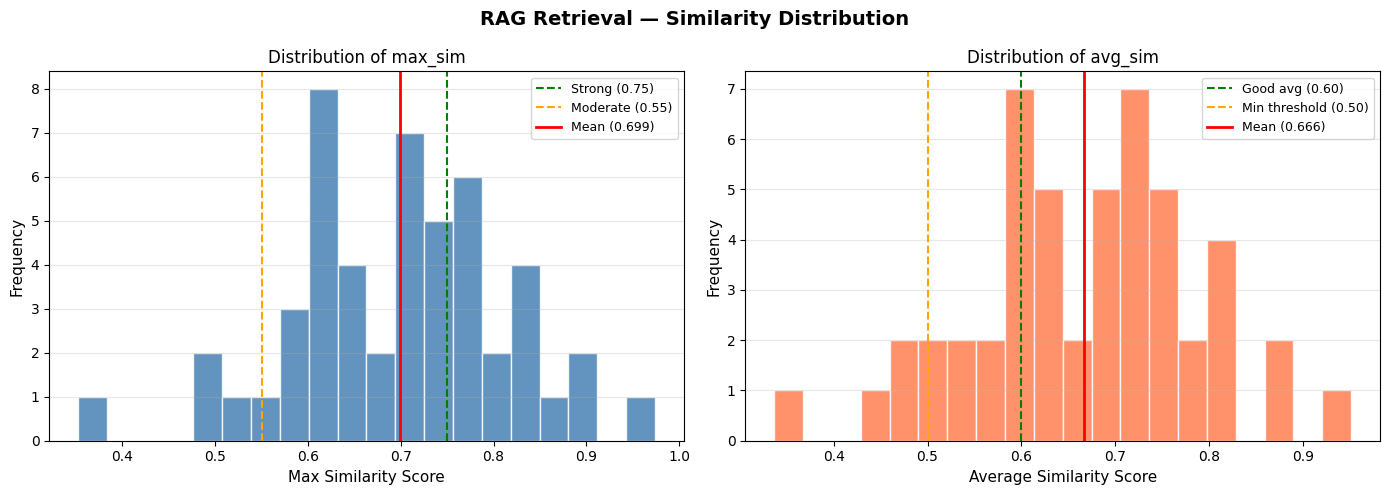

Plot saved → evaluation/reports/rag_similarity_distribution.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RAG Retrieval — Similarity Distribution', fontsize=14, fontweight='bold')

# ── Plot 1: Max similarity histogram ──────────────────────────────────────
ax1 = axes[0]
ax1.hist(all_max_sims, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(0.75, color='green',  linestyle='--', linewidth=1.5, label='Strong (0.75)')
ax1.axvline(0.55, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.55)')
ax1.axvline(np.mean(all_max_sims), color='red', linestyle='-', linewidth=2, label=f'Mean ({np.mean(all_max_sims):.3f})')
ax1.set_xlabel('Max Similarity Score', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of max_sim', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Avg similarity histogram ──────────────────────────────────────
ax2 = axes[1]
ax2.hist(all_avg_sims, bins=20, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(0.60, color='green',  linestyle='--', linewidth=1.5, label='Good avg (0.60)')
ax2.axvline(0.50, color='orange', linestyle='--', linewidth=1.5, label='Min threshold (0.50)')
ax2.axvline(np.mean(all_avg_sims), color='red', linestyle='-', linewidth=2, label=f'Mean ({np.mean(all_avg_sims):.3f})')
ax2.set_xlabel('Average Similarity Score', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of avg_sim', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../evaluation/reports/rag_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → evaluation/reports/rag_similarity_distribution.png')

## Step 11 — Knowledge Gap Rate Across Sample

Knowledge Gap Rate in sample: 14.0%
  Tickets WITH gap (flag=1)  : 7
  Tickets without gap (flag=0): 43


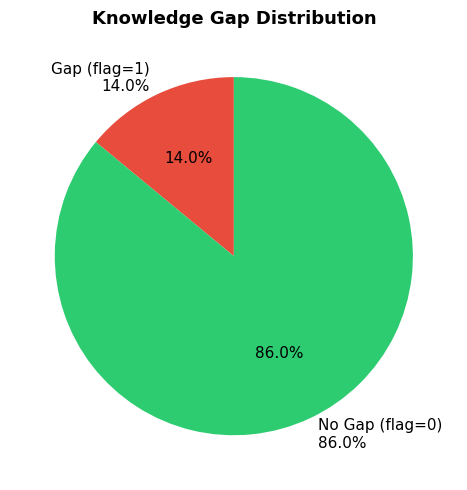

Plot saved → evaluation/reports/knowledge_gap_pie.png


In [54]:
from retrieval.knowledge_gap import compute_knowledge_gap_flag

gap_flags = [1 if s < 0.6 else 0 for s in all_max_sims]
gap_rate  = sum(gap_flags) / len(gap_flags) * 100

print(f'Knowledge Gap Rate in sample: {gap_rate:.1f}%')
print(f'  Tickets WITH gap (flag=1)  : {sum(gap_flags)}')
print(f'  Tickets without gap (flag=0): {len(gap_flags) - sum(gap_flags)}')

# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
sizes  = [sum(gap_flags), len(gap_flags) - sum(gap_flags)]
labels = [f'Gap (flag=1)\n{gap_rate:.1f}%', f'No Gap (flag=0)\n{100-gap_rate:.1f}%']
colors = ['#E74C3C', '#2ECC71']
ax.pie(sizes, labels=labels, colors=colors, startangle=90,
       autopct='%1.1f%%', textprops={'fontsize': 11})
ax.set_title('Knowledge Gap Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../evaluation/reports/knowledge_gap_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → evaluation/reports/knowledge_gap_pie.png')

In [55]:
ticket_text = """
After upgrading PyTorch, my model training is failing with a CUDA out of memory error.
Previously the same code was working fine. Now even small batch sizes cause crashes.
I am using GPU acceleration and have tried restarting the runtime, but the issue persists.
"""

In [56]:
import sys
import os

# Move one level up to project root
sys.path.append(os.path.abspath(".."))

from nlp.nlp_pipeline import run_rag_for_ticket
from retrieval.retriever import retrieve

results = retrieve(ticket_text, top_k=5,index_path="../data/retrieval/kb_index")

rag = run_rag_for_ticket(
    clean_text=ticket_text,
    intent_label="bug",
    intent_confidence=0.85,
    index_path="../data/retrieval/kb_index"
)


[FAISS Index] Loaded — 303 vectors from '../data/retrieval/kb_index.faiss'.


In [57]:
print("Incoming Ticket:")
print(ticket_text)

print("\nTop Retrieved Issues:")
for r in results:
    print(f"\nScore: {r['similarity_score']:.3f}")
    print(f"Text: {r['clean_text'][:100]}")
    print(f"Solution: {r['solution_comments'][:100]}")
    print(f"Tier: {r.get('kb_quality_tier')}")

Incoming Ticket:

After upgrading PyTorch, my model training is failing with a CUDA out of memory error.
Previously the same code was working fine. Now even small batch sizes cause crashes.
I am using GPU acceleration and have tried restarting the runtime, but the issue persists.


Top Retrieved Issues:

Score: 0.653
Text: segmentation fault in aten.lstm.data operator if batch sizes tensor is not on the cpu 🐛 describe the
Solution: this issue has already been fixed in the main branch via pr (merged january 13, 2026). the fix added
Tier: tier1_verified

Score: 0.646
Text: [release 2.11][vllm] distributed failures - free memory on device cuda:0 (19.77/22.05 gib) on startu
Solution: this is resolved now on latest reruns
Tier: tier1_verified

Score: 0.642
Text: [cuda] illegal memory read on sparsesegmentsum issue type bug have you reproduced the bug with tenso
Solution: hi , apologies for the delay, and thanks for the report. the issue is caused by invalid inputs passe
Tier: tier1_verified

In [58]:
print("\nRAG Features:")
print({
    "max_sim": rag["max_sim"],
    "avg_sim": rag["avg_sim"],
    "spread": rag["sim_spread"],
    "gap_flag": rag["knowledge_gap_flag"]
})

print("\nTier Info:")
print("Top Tier:", rag.get("top_tier"))
print("Tier1 flag:", 1 if rag.get("top_tier") == "tier1_verified" else 0)
print("Tier2 flag:", 1 if rag.get("top_tier") == "tier2_discussed" else 0)


RAG Features:
{'max_sim': 0.6527, 'avg_sim': 0.6405, 'spread': 0.0233, 'gap_flag': 0}

Tier Info:
Top Tier: tier1_verified
Tier1 flag: 1
Tier2 flag: 0
